# Frame timing study (Nsight Graphics)

This notebook reads results under `benchmark/nsight_gr_results/`, joins **frame times in ms** from `range*_frames.txt` with the matching **YAML** files, and answers:

- Which **camera range** (`range1`–`range5`) yields slower frames for each benchmark **version**.
- How **versions** compare (after **per-scene averaging**; plots are **split** for molecular vs grid scenes; aggregation across scenes is described in each section).
- How **GPU phases** in each YAML (`Range` + `RelativeFrameDuration`) map to **real milliseconds** and compare across **scenes** and **camera ranges** (section 4: **disk cache** + **filtered phases** + **bar charts** per version).

**File layout**

- **Molecular** scenes: each `rangeN` has `rangeN_1_analysis.yaml`, `rangeN_2_analysis.yaml`, `rangeN_3_analysis.yaml` and a single `rangeN_frames.txt` with **three blocks** separated by `------` (one per YAML, usually 15 lines = 15 frames per block).
- **Grid** scenes: one `rangeN_analysis.yaml` per range and `rangeN_frames.txt` (sometimes one block with as many lines as captured frames).

Injected times in each YAML entry follow `benchmark_mol_yaml.ipynb`: `real_ms = frame_total_time_ms * RelativeFrameDuration` (duration attributed to that *Range* within the frame).



In [118]:
# Requires: pandas, matplotlib, seaborn, pyyaml (install in the environment if missing)
import re
import yaml
from pathlib import Path
from statistics import mean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

# Result root: prefer benchmark/nsight_gr_results relative to this notebook or cwd.
_cand = [Path("../nsight_gr_results"), Path("benchmark/nsight_gr_results")]
NSIGHT_ROOT = next((p.resolve() for p in _cand if p.resolve().is_dir()), _cand[0].resolve())
VERSIONES = ("CS_1st", "CS_2nd", "CS_std", "CU_HYB_BIN")
RANGOS = tuple(f"range{i}" for i in range(1, 6))
TIPOS_ESCENA = ("molecular", "grid")
TITULO_TIPO_ESCENA = {"molecular": "Molecular scenes", "grid": "Grid scenes"}
VERSIONES_COMPARAR_CS_CU = ("CS_std", "CU_HYB_BIN")




In [119]:
def cargar_bloques_frames(path_txt: Path) -> list[list[float]]:
    """Return a list of blocks; each block is frame times in ms (one line = one frame)."""
    if not path_txt.is_file():
        return []
    raw = path_txt.read_text(encoding="utf-8").strip()
    if not raw:
        return []
    partes = raw.split("------")
    out = []
    for p in partes:
        if not p.strip():
            continue
        vals = [float(line.strip()) for line in p.strip().splitlines() if line.strip()]
        if vals:
            out.append(vals)
    return out


def detectar_entradas_por_frame(lista_yaml: list) -> int:
    """Heuristic: distance between consecutive repeats of the first Range (typically events per frame)."""
    if not lista_yaml:
        return 1
    primero = lista_yaml[0].get("Range")
    for i in range(1, len(lista_yaml)):
        if lista_yaml[i].get("Range") == primero:
            return i
    return len(lista_yaml)


def inyectar_tiempos_ms(lista_yaml: list, tiempos_frame_ms: list[float], entradas_por_frame: int) -> None:
    """Add to each entry: Frame_Index, Frame_Total_Time_ms, Real_Duration_ms."""
    for idx, entrada in enumerate(lista_yaml):
        fi = idx // entradas_por_frame
        if fi >= len(tiempos_frame_ms):
            tf = tiempos_frame_ms[-1] if tiempos_frame_ms else 0.0
        else:
            tf = tiempos_frame_ms[fi]
        rel = float(entrada.get("RelativeFrameDuration") or 0)
        entrada["Frame_Index"] = fi
        entrada["Frame_Total_Time_ms"] = tf
        entrada["Real_Duration_ms"] = tf * rel




In [120]:
def _yaml_load(text: str):
    try:
        return yaml.load(text, Loader=yaml.CSafeLoader)
    except AttributeError:
        return yaml.safe_load(text)


def yaml_paths_para_rango(yaml_dir: Path, rango: str) -> tuple[str, list[Path]]:
    """Return ('molecular'|'grid', [paths...])."""
    p1 = yaml_dir / f"{rango}_1_analysis.yaml"
    if p1.is_file():
        return "molecular", [yaml_dir / f"{rango}_1_analysis.yaml", yaml_dir / f"{rango}_2_analysis.yaml", yaml_dir / f"{rango}_3_analysis.yaml"]
    p0 = yaml_dir / f"{rango}_analysis.yaml"
    if p0.is_file():
        return "grid", [p0]
    return "", []


def recolectar_filas_frame(version: str, escena: str, yaml_dir: Path) -> list[dict]:
    """One row per (version, scene, range, yaml_replica, frame_index) with frame time in ms."""
    filas = []
    for rango in RANGOS:
        tipo, ypaths = yaml_paths_para_rango(yaml_dir, rango)
        if not ypaths:
            continue
        frames_txt = yaml_dir / f"{rango}_frames.txt"
        bloques = cargar_bloques_frames(frames_txt)
        if tipo == "molecular":
            if len(bloques) < len(ypaths):
                continue
            for rep, ypath in enumerate(ypaths):
                if not ypath.is_file():
                    continue
                tiempos = bloques[rep] if rep < len(bloques) else []
                if not tiempos:
                    continue
                for fi, ms in enumerate(tiempos):
                    filas.append({
                        "Version": version,
                        "Escena": escena,
                        "Tipo": "molecular",
                        "Range": rango,
                        "YamlReplica": rep + 1,
                        "FrameIndex": fi,
                        "FrameTime_ms": ms,
                    })
        else:
            if not bloques:
                continue
            tiempos = bloques[0]
            ypath = ypaths[0]
            if not ypath.is_file() or not tiempos:
                continue
            for fi, ms in enumerate(tiempos):
                filas.append({
                    "Version": version,
                    "Escena": escena,
                    "Tipo": "grid",
                    "Range": rango,
                    "YamlReplica": 0,
                    "FrameIndex": fi,
                    "FrameTime_ms": ms,
                })
    return filas


def escanear_todo(nsight_root: Path) -> pd.DataFrame:
    filas = []
    for vdir in sorted(nsight_root.iterdir()):
        if not vdir.is_dir() or vdir.name not in VERSIONES:
            continue
        for sdir in sorted(vdir.iterdir()):
            if not sdir.is_dir():
                continue
            yaml_dir = sdir / "YAML"
            if not yaml_dir.is_dir():
                continue
            filas.extend(recolectar_filas_frame(vdir.name, sdir.name, yaml_dir))
    return pd.DataFrame(filas)


def fase_filas_desde_yaml(
    version: str,
    scene: str,
    scene_type: str,
    camera_range: str,
    yaml_replica: int,
    tiempos_ms: list[float],
    data: object,
) -> list[dict]:
    """Expand one YAML capture: one row per (frame, GPU phase) with attributed duration in ms."""
    if not isinstance(data, list) or not data:
        return []
    epf = detectar_entradas_por_frame(data)
    filas: list[dict] = []
    for idx, entrada in enumerate(data):
        fi = idx // epf
        if fi >= len(tiempos_ms):
            tf = tiempos_ms[-1] if tiempos_ms else 0.0
        else:
            tf = tiempos_ms[fi]
        rel = float(entrada.get("RelativeFrameDuration") or 0)
        phase = entrada.get("Range")
        if phase is None:
            continue
        filas.append(
            {
                "Version": version,
                "Scene": scene,
                "SceneType": scene_type,
                "CameraRange": camera_range,
                "YamlReplica": yaml_replica,
                "FrameIndex": fi,
                "Phase": str(phase),
                "RelFrame": rel,
                "FrameTotal_ms": tf,
                "RealDuration_ms": tf * rel,
            }
        )
    return filas


def recolectar_fases_scene(version: str, scene: str, yaml_dir: Path) -> list[dict]:
    """Collect phase-duration rows for one scene folder (all camera ranges + YAML replicas)."""
    out: list[dict] = []
    for rango in RANGOS:
        tipo, ypaths = yaml_paths_para_rango(yaml_dir, rango)
        if not ypaths:
            continue
        bloques = cargar_bloques_frames(yaml_dir / f"{rango}_frames.txt")
        if tipo == "molecular":
            if len(bloques) < len(ypaths):
                continue
            for rep, ypath in enumerate(ypaths):
                if not ypath.is_file():
                    continue
                tiempos = bloques[rep] if rep < len(bloques) else []
                if not tiempos:
                    continue
                data = _yaml_load(ypath.read_text(encoding="utf-8"))
                out.extend(
                    fase_filas_desde_yaml(
                        version, scene, "molecular", rango, rep + 1, tiempos, data
                    )
                )
        else:
            if not bloques:
                continue
            tiempos = bloques[0]
            if not ypaths[0].is_file() or not tiempos:
                continue
            data = _yaml_load(ypaths[0].read_text(encoding="utf-8"))
            out.extend(
                fase_filas_desde_yaml(version, scene, "grid", rango, 0, tiempos, data)
            )
    return out


def escanear_fases(nsight_root: Path) -> pd.DataFrame:
    """Scan all versions/scenes; join frame *.txt timings with YAML phases (RelativeFrameDuration)."""
    filas: list[dict] = []
    for vdir in sorted(nsight_root.iterdir()):
        if not vdir.is_dir() or vdir.name not in VERSIONES:
            continue
        for sdir in sorted(vdir.iterdir()):
            if not sdir.is_dir():
                continue
            yaml_dir = sdir / "YAML"
            if not yaml_dir.is_dir():
                continue
            filas.extend(recolectar_fases_scene(vdir.name, sdir.name, yaml_dir))
    return pd.DataFrame(filas)


def inyectar_en_archivos(nsight_root: Path, max_archivos: int | None = None) -> int:
    """Load YAML, inject times, write *_with_times.yaml (optional; can be expensive)."""
    n = 0
    for vdir in sorted(nsight_root.iterdir()):
        if not vdir.is_dir() or vdir.name not in VERSIONES:
            continue
        for sdir in sorted(vdir.iterdir()):
            if not sdir.is_dir():
                continue
            yaml_dir = sdir / "YAML"
            if not yaml_dir.is_dir():
                continue
            for rango in RANGOS:
                tipo, ypaths = yaml_paths_para_rango(yaml_dir, rango)
                if not ypaths:
                    continue
                bloques = cargar_bloques_frames(yaml_dir / f"{rango}_frames.txt")
                if tipo == "molecular":
                    for rep, ypath in enumerate(ypaths):
                        if not ypath.is_file() or rep >= len(bloques):
                            continue
                        data = _yaml_load(ypath.read_text(encoding="utf-8"))
                        if not isinstance(data, list):
                            continue
                        epf = detectar_entradas_por_frame(data)
                        inyectar_tiempos_ms(data, bloques[rep], epf)
                        out = ypath.with_name(ypath.stem + "_with_times.yaml")
                        out.write_text(yaml.safe_dump(data, allow_unicode=True, sort_keys=False), encoding="utf-8")
                        n += 1
                        if max_archivos is not None and n >= max_archivos:
                            return n
                else:
                    if not ypaths[0].is_file() or not bloques:
                        continue
                    data = _yaml_load(ypaths[0].read_text(encoding="utf-8"))
                    if not isinstance(data, list):
                        continue
                    epf = detectar_entradas_por_frame(data)
                    inyectar_tiempos_ms(data, bloques[0], epf)
                    out = ypaths[0].with_name(ypaths[0].stem + "_with_times.yaml")
                    out.write_text(yaml.safe_dump(data, allow_unicode=True, sort_keys=False), encoding="utf-8")
                    n += 1
                    if max_archivos is not None and n >= max_archivos:
                        return n
    return n




## 1. Load frame timing table

Each row is one frame: total frame time in ms (as in the `.txt`), with version, scene, and camera range metadata.



In [121]:
df_frames = escanear_todo(NSIGHT_ROOT)
print("Rows:", len(df_frames))
if df_frames.empty:
    raise SystemExit(f"No data found under {NSIGHT_ROOT}. Check NSIGHT_ROOT.")

df_frames["Range"] = pd.Categorical(df_frames["Range"], categories=list(RANGOS), ordered=True)
df_frames["RangeNum"] = df_frames["Range"].astype(str).str.replace("range", "", regex=False).astype(int)
df_frames.head(45)




Rows: 6615


,Version,Escena,Tipo,Range,YamlReplica,FrameIndex,FrameTime_ms,RangeNum
0,CS_1st,1aga,molecular,range1,1,0,70.380,1
1,CS_1st,1aga,molecular,range1,1,1,70.362,1
2,CS_1st,1aga,molecular,range1,1,2,70.305,1
3,CS_1st,1aga,molecular,range1,1,3,70.273,1
4,CS_1st,1aga,molecular,range1,1,4,70.361,1
5,CS_1st,1aga,molecular,range1,1,5,70.295,1
6,CS_1st,1aga,molecular,range1,1,6,70.277,1
7,CS_1st,1aga,molecular,range1,1,7,70.253,1
8,CS_1st,1aga,molecular,range1,1,8,70.335,1
9,CS_1st,1aga,molecular,range1,1,9,70.336,1


In [122]:
df_frames.query("Version == 'CU_HYB_BIN'").head(45)

,Version,Escena,Tipo,Range,YamlReplica,FrameIndex,FrameTime_ms,RangeNum
4815,CU_HYB_BIN,1aga,molecular,range1,1,0,2.779,1
4816,CU_HYB_BIN,1aga,molecular,range1,1,1,4.168,1
4817,CU_HYB_BIN,1aga,molecular,range1,1,2,2.995,1
4818,CU_HYB_BIN,1aga,molecular,range1,1,3,4.204,1
4819,CU_HYB_BIN,1aga,molecular,range1,1,4,3.192,1
4820,CU_HYB_BIN,1aga,molecular,range1,1,5,2.997,1
4821,CU_HYB_BIN,1aga,molecular,range1,1,6,2.899,1
4822,CU_HYB_BIN,1aga,molecular,range1,1,7,3.648,1
4823,CU_HYB_BIN,1aga,molecular,range1,1,8,2.810,1
4824,CU_HYB_BIN,1aga,molecular,range1,1,9,3.191,1


## 2. Per-scene mean time (ms) over YAML replicas and frames

For each **version × scene × range**, `FrameTime_ms` is averaged over **all YAML replicas** and **all frames** of that scene for that range. Rows from **different scenes are not mixed** here.

There are **two blocks** (molecular / grid): in each, the wide table and `relplot` only compare scenes of that **type** — same setup (`hue=Scene`, facets by **version**).

After each `relplot`, extra plots compare **CS_std** vs **CU_HYB_BIN**: **one per scene** of that type (same `Mean_ms` by `range*`).



Molecular scenes


Range              range1   range2   range3   range4  range5
Version    Scene                                            
CS_1st     1aga   165.887  100.733   27.190   11.684   7.637
           1c0o   148.520   36.470   15.492    8.542   4.657
           2mjq    95.669   21.079    8.653    4.847   2.562
           8wql    19.341    4.365    1.724    1.705   1.532
CS_2nd     1aga     2.286    3.079    4.332    4.543   5.122
           1c0o    25.116   77.352  110.067      NaN     NaN
           2mjq    68.014  322.073  529.386  629.681     NaN
CS_std     1aga     1.808    1.876    1.947    1.738   1.741
           1c0o     2.634    2.557    2.450    2.187   2.031
           2mjq     2.445    2.898    3.110    2.469   2.646
           8wql     2.091    2.682    2.629    3.034   2.786
CU_HYB_BIN 1aga     3.106    2.995    2.809    2.421   2.835
           1c0o     3.002    2.885    2.922    3.116   3.430
           2mjq     3.321    3.558    3.494    3.687   3.651
           8wql     3.783    4.033    2.526    2.562   2.760

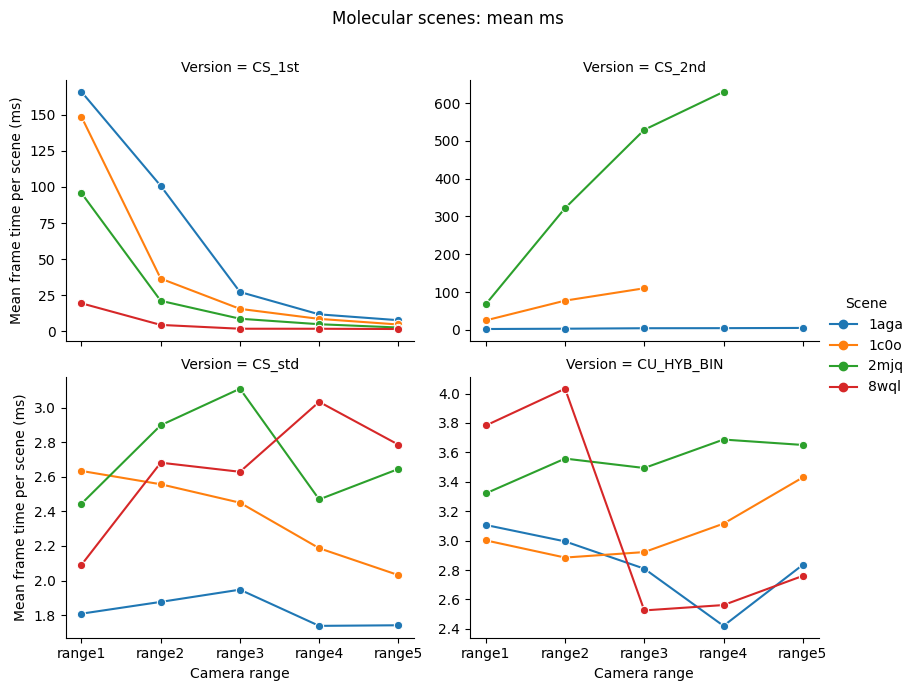

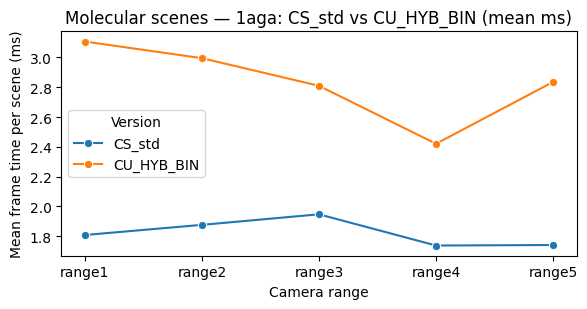

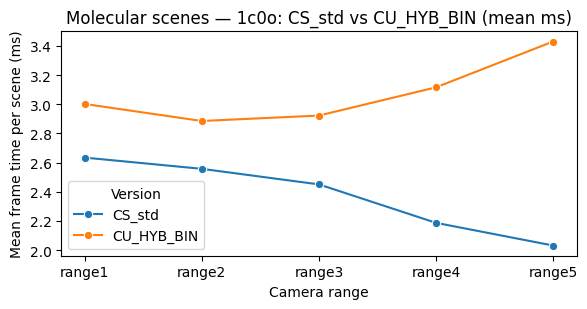

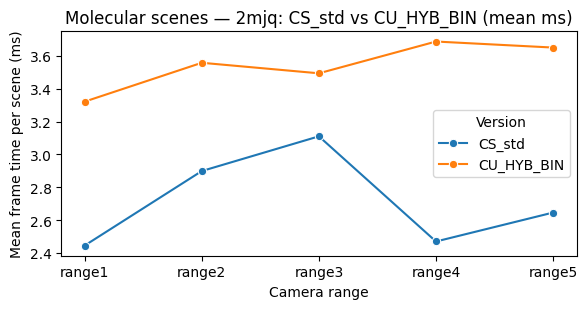

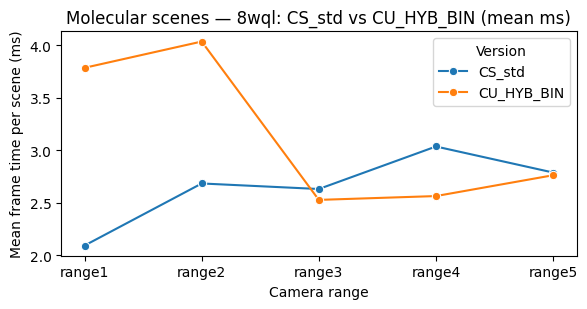

Grid scenes


Range              range1  range2  range3   range4   range5
Version    Scene                                           
CS_1st     grid1  196.149  20.215   3.957    2.740    2.226
           grid2  163.731   2.121   1.768    1.617    1.624
           grid3   42.003   1.803   1.557    1.508    1.789
           grid4  205.888   1.902   1.728    1.607    1.504
CS_2nd     grid1    2.118   1.709   2.264    2.500    3.572
           grid2    1.658   4.287  31.208   66.823  105.273
           grid3    1.581   2.686  36.099  142.422  290.017
CS_std     grid1    1.706   2.041   2.041    2.206    2.053
           grid2    1.712   1.779   2.131    2.071    3.379
           grid3    1.655   1.652   1.640    1.650    1.620
           grid4    2.173   2.184   2.405    2.271    2.770
CU_HYB_BIN grid1    3.620   2.742   3.413    2.796    2.823
           grid2    2.363   2.639   2.759    2.599    2.757
           grid3    2.443   2.524   1.952    1.839    2.047
           grid4    3.218   3.182   2.333    2.492    2.475

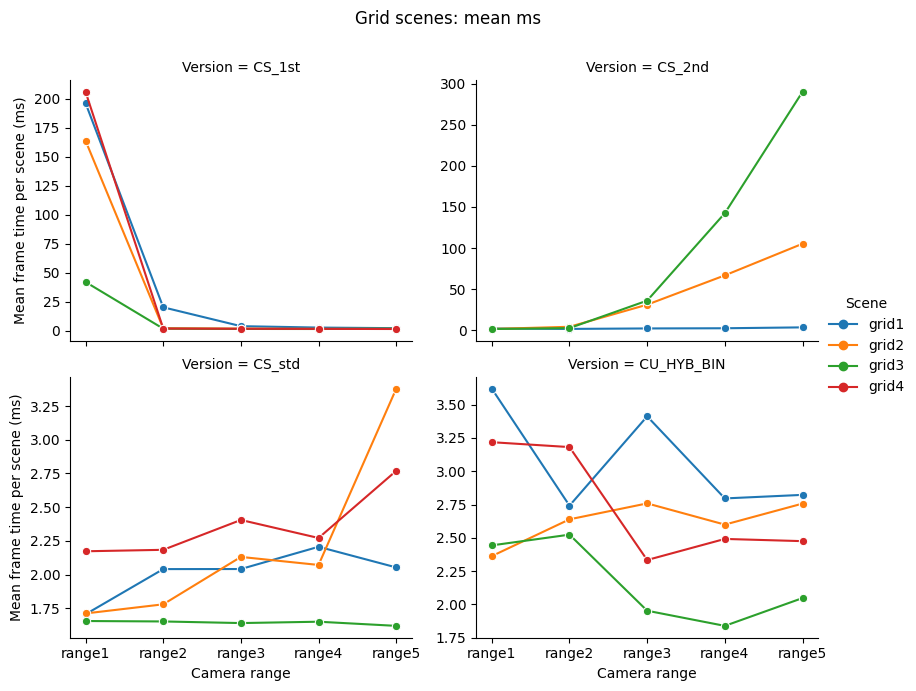

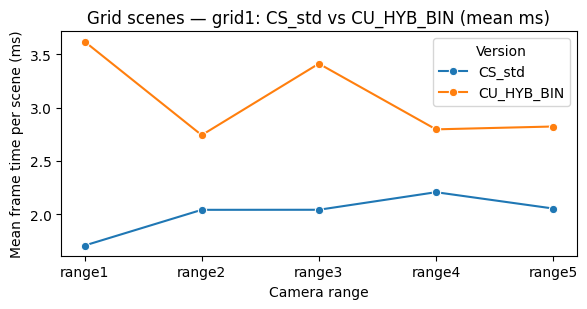

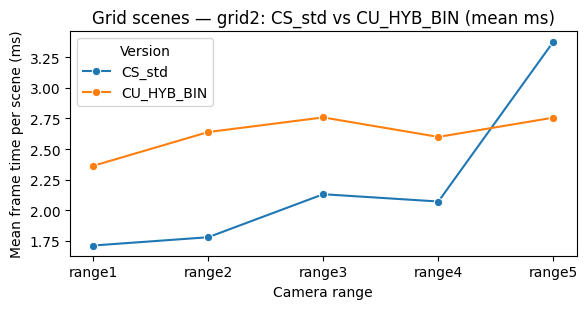

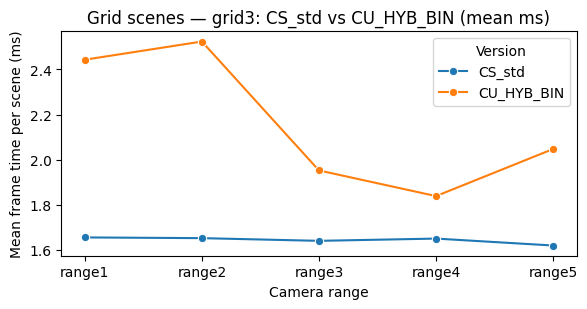

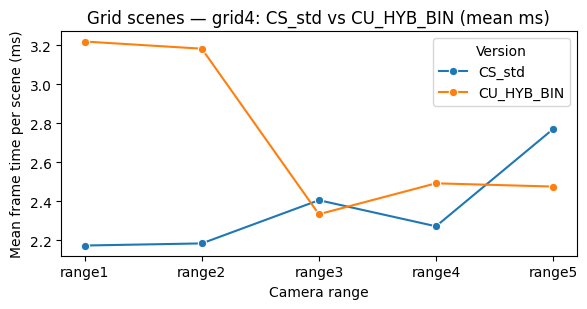

In [123]:
df_scene_range = (
    df_frames.groupby(["Version", "Escena", "Tipo", "Range"], observed=True)["FrameTime_ms"]
    .agg(Mean_ms="mean", Std_ms="std", N_samples="count")
    .reset_index()
)
df_scene_range["Range"] = pd.Categorical(df_scene_range["Range"], categories=list(RANGOS), ordered=True)

for tipo in TIPOS_ESCENA:
    sub = df_scene_range[df_scene_range["Tipo"] == tipo]
    agg_pivot = (
        sub.pivot_table(
            index=["Version", "Escena"],
            columns="Range",
            values="Mean_ms",
            observed=True,
        )
        .reindex(columns=list(RANGOS))
    )
    if isinstance(agg_pivot.index, pd.MultiIndex):
        agg_pivot.index = agg_pivot.index.set_names(["Version", "Scene"])
    print(TITULO_TIPO_ESCENA[tipo])
    display(agg_pivot.round(3))

    if sub.empty:
        print("(no rows for this scene type)\n")
        continue

    sub_plot = sub.rename(columns={"Escena": "Scene"})
    g = sns.relplot(
        data=sub_plot,
        x="Range",
        y="Mean_ms",
        hue="Scene",
        col="Version",
        col_wrap=2,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.5,
        aspect=1.2,
    )
    g.set_axis_labels("Camera range", "Mean frame time per scene (ms)")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(
        f"{TITULO_TIPO_ESCENA[tipo]}: mean ms "
    )
    plt.show()

    cmp = sub[sub["Version"].isin(VERSIONES_COMPARAR_CS_CU)].copy()
    if not cmp.empty:
        cmp_plot = cmp.rename(columns={"Escena": "Scene"})
        for escena in sorted(cmp_plot["Scene"].unique()):
            one = cmp_plot[cmp_plot["Scene"] == escena]
            plt.figure(figsize=(6, 3.2))
            sns.lineplot(
                data=one,
                x="Range",
                y="Mean_ms",
                hue="Version",
                hue_order=list(VERSIONES_COMPARAR_CS_CU),
                marker="o",
                dashes=False,
            )
            plt.xlabel("Camera range")
            plt.ylabel("Mean frame time per scene (ms)")
            plt.title(
                f"{TITULO_TIPO_ESCENA[tipo]} — {escena}: "
                "CS_std vs CU_HYB_BIN (mean ms)"
            )
            plt.tight_layout()
            plt.show()




## 3. Per-scene mean FPS (same layout as section 2)

For each row we define **FPS** as `1000 / FrameTime_ms` (ms per frame → frames per second). For each **version × scene × range**, we take the **mean FPS** over all YAML replicas and frames (NaNs from invalid/zero times are ignored by `mean`).

Wide tables, `relplot` by scene type, then **CS_std vs CU_HYB_BIN** per scene — same structure as section 2, in FPS units.



Molecular scenes


Range             range1  range2  range3  range4  range5
Version    Scene                                        
CS_1st     1aga     7.99   13.25   38.85   87.64  135.42
           1c0o     9.51   29.03   66.48  118.19  215.18
           2mjq    18.84   53.92  115.79  209.69  395.81
           8wql   119.56  235.92  594.84  656.93  724.30
CS_2nd     1aga   443.51  328.07  233.40  220.17  196.39
           1c0o    43.56   12.94    9.11     NaN     NaN
           2mjq    17.73    3.13    1.90    1.61     NaN
CS_std     1aga   591.99  588.40  572.21  619.73  613.57
           1c0o   411.64  396.98  418.48  476.86  521.06
           2mjq   410.78  353.04  332.73  406.83  384.51
           8wql   501.07  378.72  384.42  335.03  362.92
CU_HYB_BIN 1aga   330.78  342.42  363.39  416.13  369.80
           1c0o   337.25  348.07  343.91  322.68  298.37
           2mjq   321.31  291.46  287.98  277.12  289.91
           8wql   268.19  249.63  398.56  394.37  384.80

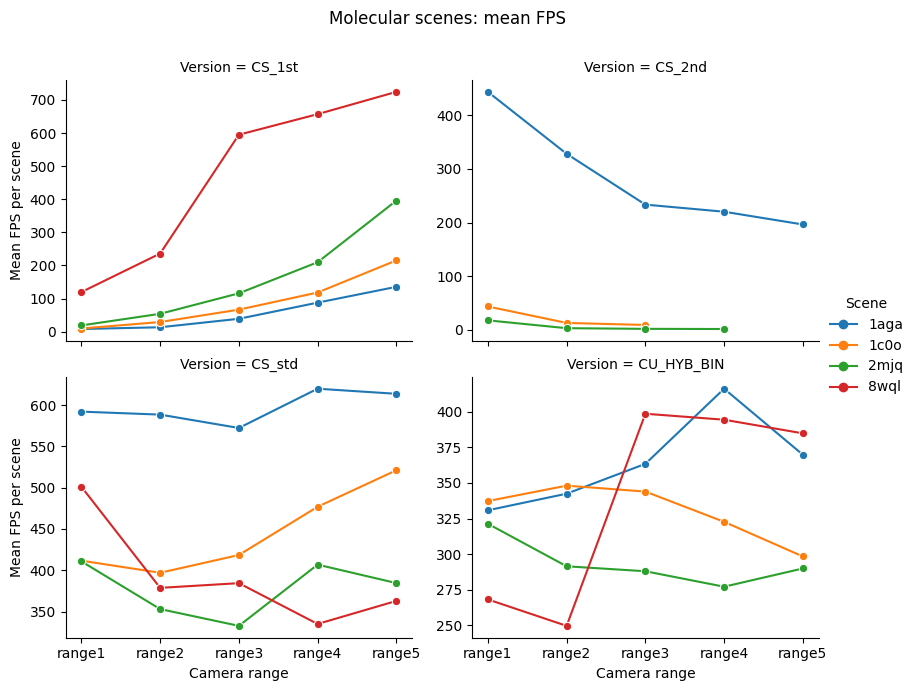

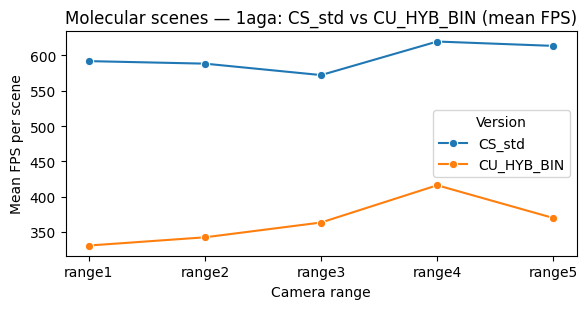

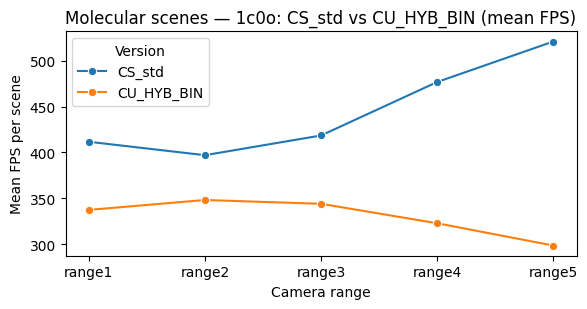

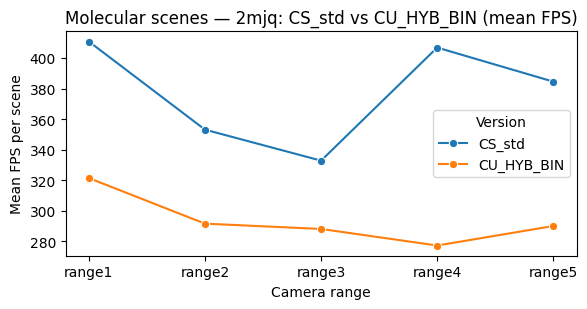

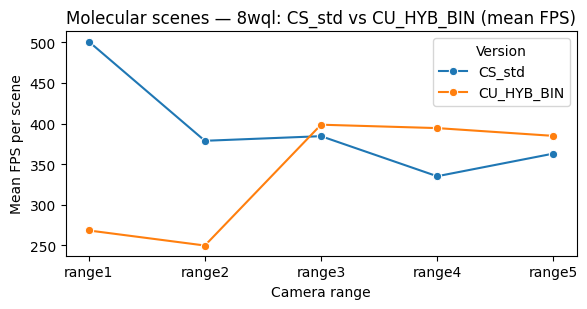

Grid scenes


Range             range1  range2  range3  range4  range5
Version    Scene                                        
CS_1st     grid1    5.10   49.47  253.43  367.80  470.48
           grid2    6.11  485.87  613.95  666.44  673.50
           grid3   23.82  573.80  674.55  691.91  616.79
           grid4    4.87  538.32  631.07  677.36  698.54
CS_2nd     grid1  555.21  610.24  451.34  402.86  281.06
           grid2  633.05  233.33   32.05   14.97    9.50
           grid3  658.69  372.52   27.70    7.02    3.45
CS_std     grid1  610.19  552.92  538.83  514.11  545.27
           grid2  611.91  602.27  523.74  543.10  333.84
           grid3  623.09  632.83  625.13  629.83  631.61
           grid4  527.42  515.60  465.81  492.72  404.13
CU_HYB_BIN grid1  278.54  366.27  300.33  360.15  356.06
           grid2  425.23  383.23  367.80  388.61  378.38
           grid3  414.55  406.14  543.85  560.48  521.80
           grid4  313.50  319.39  431.10  404.65  406.24

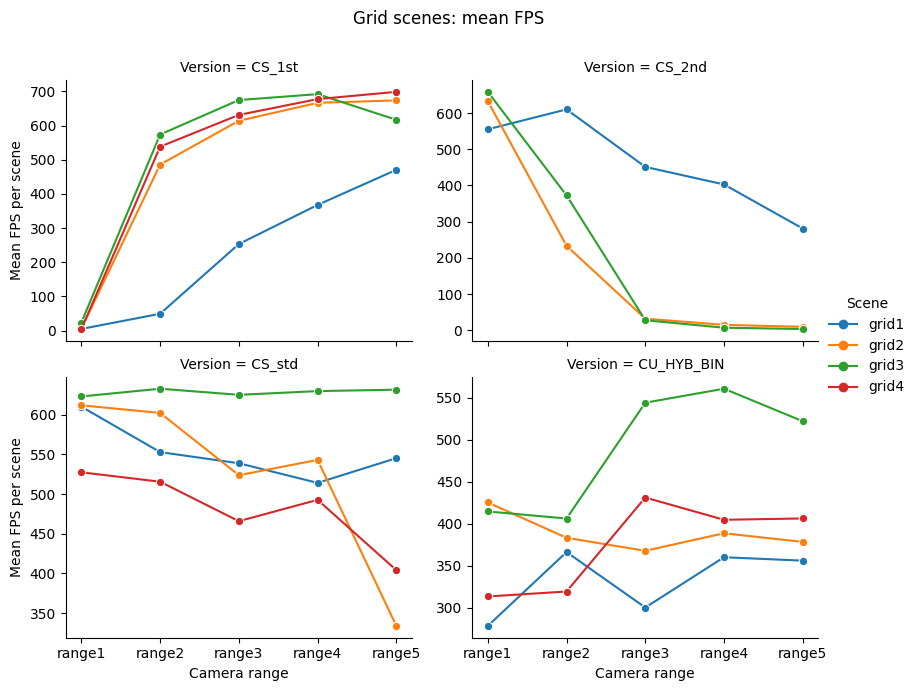

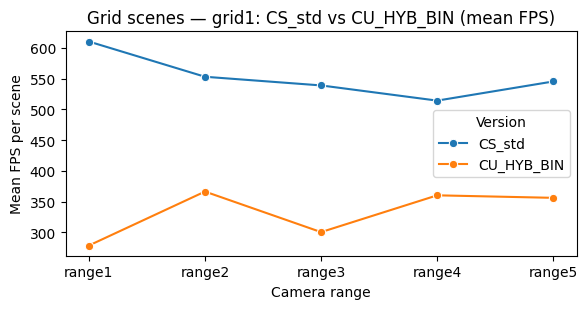

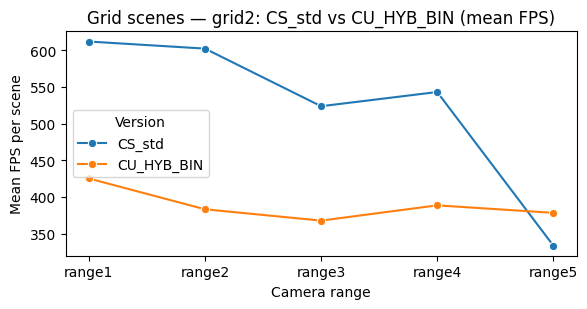

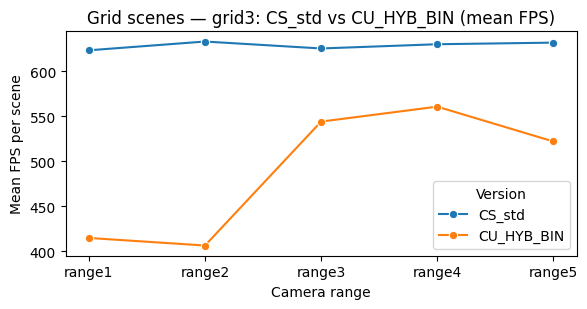

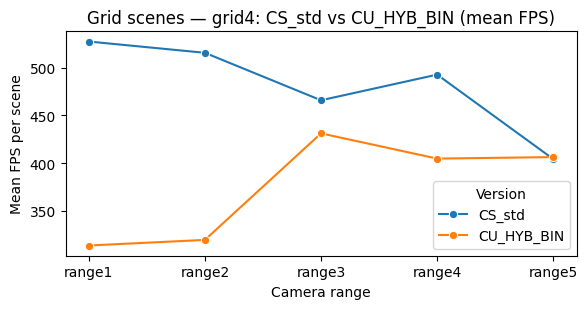

In [124]:
df_frames_fps = df_frames.copy()
df_frames_fps["Fps"] = np.where(
    df_frames_fps["FrameTime_ms"] > 0,
    1000.0 / df_frames_fps["FrameTime_ms"],
    np.nan,
)

df_scene_fps = (
    df_frames_fps.groupby(["Version", "Escena", "Tipo", "Range"], observed=True)["Fps"]
    .agg(Mean_fps="mean", Std_fps="std", N_samples="count")
    .reset_index()
)
df_scene_fps["Range"] = pd.Categorical(df_scene_fps["Range"], categories=list(RANGOS), ordered=True)

for tipo in TIPOS_ESCENA:
    sub = df_scene_fps[df_scene_fps["Tipo"] == tipo]
    agg_pivot = (
        sub.pivot_table(
            index=["Version", "Escena"],
            columns="Range",
            values="Mean_fps",
            observed=True,
        )
        .reindex(columns=list(RANGOS))
    )
    if isinstance(agg_pivot.index, pd.MultiIndex):
        agg_pivot.index = agg_pivot.index.set_names(["Version", "Scene"])
    print(TITULO_TIPO_ESCENA[tipo])
    display(agg_pivot.round(2))

    if sub.empty:
        print("(no rows for this scene type)\n")
        continue

    sub_plot = sub.rename(columns={"Escena": "Scene"})
    g = sns.relplot(
        data=sub_plot,
        x="Range",
        y="Mean_fps",
        hue="Scene",
        col="Version",
        col_wrap=2,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.5,
        aspect=1.2,
    )
    g.set_axis_labels("Camera range", "Mean FPS per scene")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(
        f"{TITULO_TIPO_ESCENA[tipo]}: mean FPS "
    )
    plt.show()

    cmp = sub[sub["Version"].isin(VERSIONES_COMPARAR_CS_CU)].copy()
    if not cmp.empty:
        cmp_plot = cmp.rename(columns={"Escena": "Scene"})
        for escena in sorted(cmp_plot["Scene"].unique()):
            one = cmp_plot[cmp_plot["Scene"] == escena]
            plt.figure(figsize=(6, 3.2))
            sns.lineplot(
                data=one,
                x="Range",
                y="Mean_fps",
                hue="Version",
                hue_order=list(VERSIONES_COMPARAR_CS_CU),
                marker="o",
                dashes=False,
            )
            plt.xlabel("Camera range")
            plt.ylabel("Mean FPS per scene")
            plt.title(
                f"{TITULO_TIPO_ESCENA[tipo]} — {escena}: "
                "CS_std vs CU_HYB_BIN (mean FPS)"
            )
            plt.tight_layout()
            plt.show()




## 4. GPU phase timing (cached, filtered phases, bar charts)

Each YAML entry contributes **`RealDuration_ms = FrameTotal_ms * RelativeFrameDuration`** for its GPU **phase** (`Range` field).

The next cell loads a **pickle cache** under `benchmark/nsight_analysis/` (`phase_timing_rows.pkl` + `phase_timing_rows.meta.json`) so you do not rescan all YAML on every tweak. Set **`FORCE_PHASE_CACHE_REBUILD = True`** once after changing data under `NSIGHT_ROOT`, run the cell, then set it back to **`False`**.

**CS_2nd note:** Nsight YAML uses **Bbox** in the phase names (e.g. `Sphere Bbox Extraction Shader`), not `Sphere Extraction Shader`.

Only the **phase names in `PHASES_BY_VERSION`** are used (per benchmark version). The following cells aggregate **mean ms** over frames and YAML replicas, then draw **grouped bar charts**: **x** = YAML phase, **y** = mean real duration (ms), **hue** = scene. **One figure per version and scene type**, with **five subplots** in a grid of at most **three** columns per row (extra rows as needed) for `range1` through `range5`.



In [125]:
import json as _json
from IPython.display import Markdown

# Set True once after refreshing nsight_gr_results, then False again for fast reloads.
FORCE_PHASE_CACHE_REBUILD = False

PHASE_CACHE_DIR = NSIGHT_ROOT.parent / "nsight_analysis"
PHASE_CACHE_PKL = PHASE_CACHE_DIR / "phase_timing_rows.pkl"
PHASE_CACHE_META = PHASE_CACHE_DIR / "phase_timing_rows.meta.json"

PHASES_BY_VERSION = {
    "CS_1st": (
        "Sphere Shader",
        "Cylinder Shader",
    ),
    "CS_2nd": (
        "Sphere Bbox Extraction Shader",
        "Sphere Bbox Intersection Shader",
        "Cylinder Bbox Extraction Shader",
        "Cylinder Bbox Intersection Shader",
    ),
    "CS_std": (
        "Sphere Culling Shader",
        "Draw Spheres",
        "Cylinder Culling Shader",
        "Draw Cylinders",
    ),
    "CU_HYB_BIN": (
        "Cylinder: Small Raster",
        "Cylinder: Tiled Raster WG",
        "Cylinder: Expand WorkGroups",
        "Cylinder: Sort+RLE+TileOffsets",
        "Cylinder: Classify",
        "Sphere: Small Raster",
        "Sphere: Tiled Raster WG",
        "Sphere: Expand WorkGroups",
        "Sphere: Sort+RLE+TileOffsets",
        "Sphere: Classify",
    ),
}


def load_or_build_phase_rows(force: bool = False) -> pd.DataFrame:
    root_s = str(NSIGHT_ROOT.resolve())
    meta_ok = False
    if not force and PHASE_CACHE_PKL.is_file() and PHASE_CACHE_META.is_file():
        try:
            meta = _json.loads(PHASE_CACHE_META.read_text(encoding="utf-8"))
            meta_ok = meta.get("nsight_root") == root_s
        except Exception:
            meta_ok = False
    if meta_ok:
        df = pd.read_pickle(PHASE_CACHE_PKL)
        print(f"Loaded phase cache: {len(df)} rows from {PHASE_CACHE_PKL.name}")
        return df
    print("Building phase table (slow first time)…")
    df = escanear_fases(NSIGHT_ROOT)
    PHASE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    df.to_pickle(PHASE_CACHE_PKL)
    PHASE_CACHE_META.write_text(
        _json.dumps({"nsight_root": root_s, "n_rows": len(df)}, indent=2),
        encoding="utf-8",
    )
    print(f"Wrote phase cache: {len(df)} rows -> {PHASE_CACHE_PKL}")
    return df


df_phases_raw = load_or_build_phase_rows(force=FORCE_PHASE_CACHE_REBUILD)
if df_phases_raw.empty:
    raise SystemExit("Phase table is empty.")

df_phases_raw["CameraRange"] = pd.Categorical(
    df_phases_raw["CameraRange"], categories=list(RANGOS), ordered=True
)
# Break global categorical levels on Scene/SceneType (pickle/concat keeps all categories → wrong legends)
df_phases_raw["Scene"] = df_phases_raw["Scene"].astype(str)
df_phases_raw["SceneType"] = df_phases_raw["SceneType"].astype(str)
df_phases_raw.head(3)


Loaded phase cache: 60120 rows from phase_timing_rows.pkl


,Version,Scene,SceneType,CameraRange,YamlReplica,FrameIndex,Phase,RelFrame,FrameTotal_ms,RealDuration_ms
0,CS_1st,1aga,molecular,range1,1,0,Cleaning Shader,0.007356,70.38,0.517730
1,CS_1st,1aga,molecular,range1,1,0,Sphere Shader,0.415523,70.38,29.244485
2,CS_1st,1aga,molecular,range1,1,0,Cylinder Shader,0.576222,70.38,40.554488


In [126]:
parts = []
for v, phases in PHASES_BY_VERSION.items():
    sub = df_phases_raw[(df_phases_raw["Version"] == v) & (df_phases_raw["Phase"].isin(phases))]
    parts.append(sub)
df_phases_sel = pd.concat(parts, ignore_index=True)
print("Filtered phase rows:", len(df_phases_sel))
df_phases_sel["Scene"] = df_phases_sel["Scene"].astype(str)
df_phases_sel["SceneType"] = df_phases_sel["SceneType"].astype(str)

agg_phase_bars = (
    df_phases_sel.groupby(
        ["Version", "Scene", "SceneType", "CameraRange", "Phase"],
        observed=False,
    )["RealDuration_ms"]
    .mean()
    .reset_index(name="Mean_ms")
)
agg_phase_bars["CameraRange"] = pd.Categorical(
    agg_phase_bars["CameraRange"], categories=list(RANGOS), ordered=True
)
# Plain strings so hue legends never inherit the full global scene list
agg_phase_bars["Scene"] = agg_phase_bars["Scene"].astype(str)
agg_phase_bars["SceneType"] = agg_phase_bars["SceneType"].astype(str)
agg_phase_bars.head(12)


Filtered phase rows: 28935


,Version,Scene,SceneType,CameraRange,Phase,Mean_ms
0,CS_1st,1aga,grid,range1,Cylinder Bbox Extraction Shader,NaN
1,CS_1st,1aga,grid,range1,Cylinder Bbox Intersection Shader,NaN
2,CS_1st,1aga,grid,range1,Cylinder Culling Shader,NaN
3,CS_1st,1aga,grid,range1,Cylinder Shader,NaN
4,CS_1st,1aga,grid,range1,Cylinder: Classify,NaN
5,CS_1st,1aga,grid,range1,Cylinder: Expand WorkGroups,NaN
6,CS_1st,1aga,grid,range1,Cylinder: Small Raster,NaN
7,CS_1st,1aga,grid,range1,Cylinder: Sort+RLE+TileOffsets,NaN
8,CS_1st,1aga,grid,range1,Cylinder: Tiled Raster WG,NaN
9,CS_1st,1aga,grid,range1,Draw Cylinders,NaN


## 4 — Version `CS_1st`: selected phases (mean ms)

### Molecular scenes

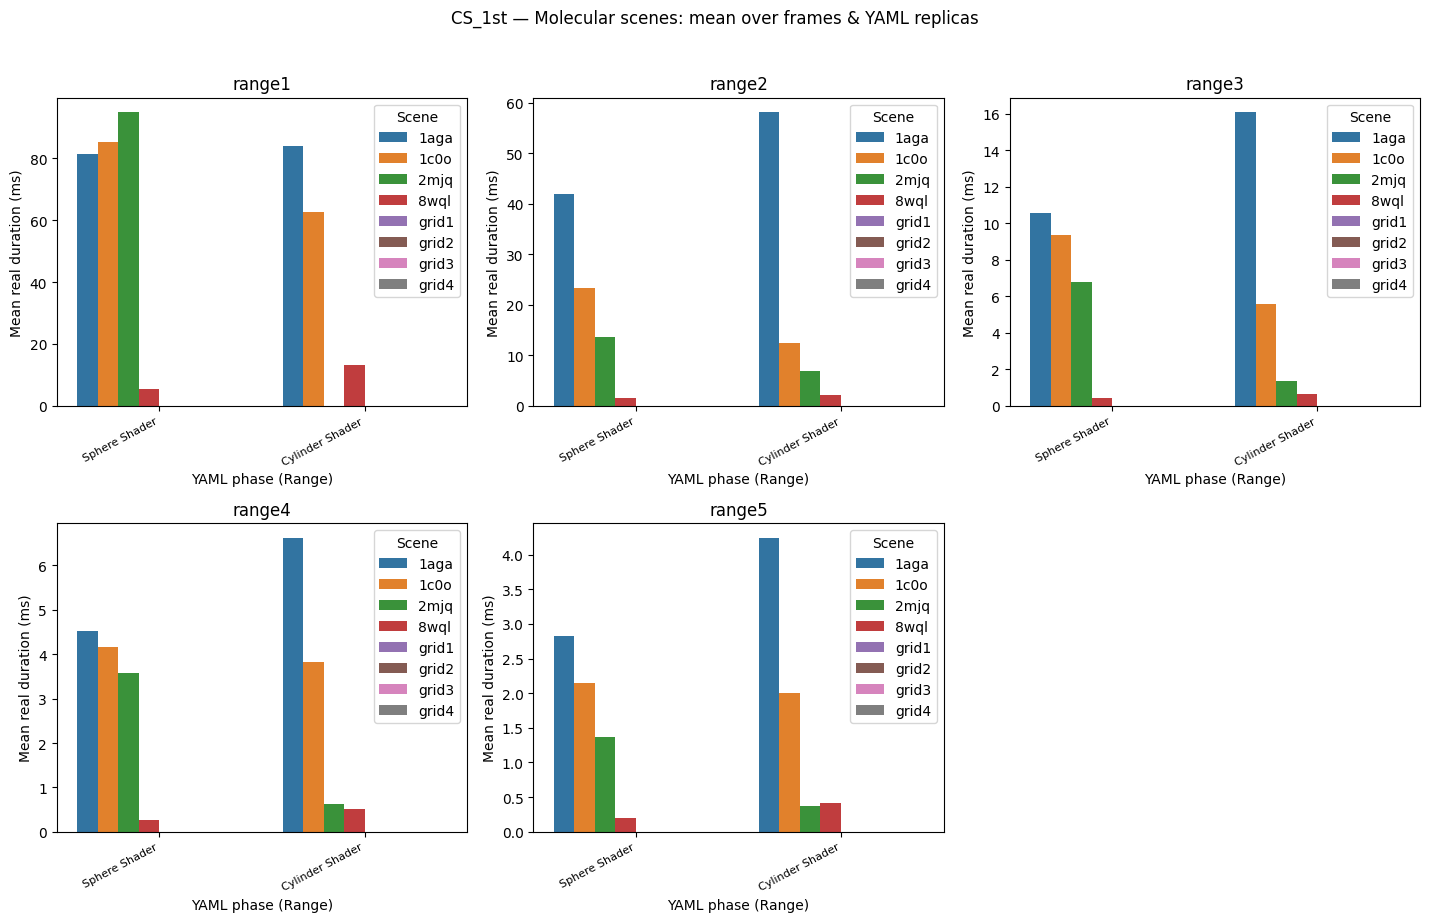

### Grid scenes

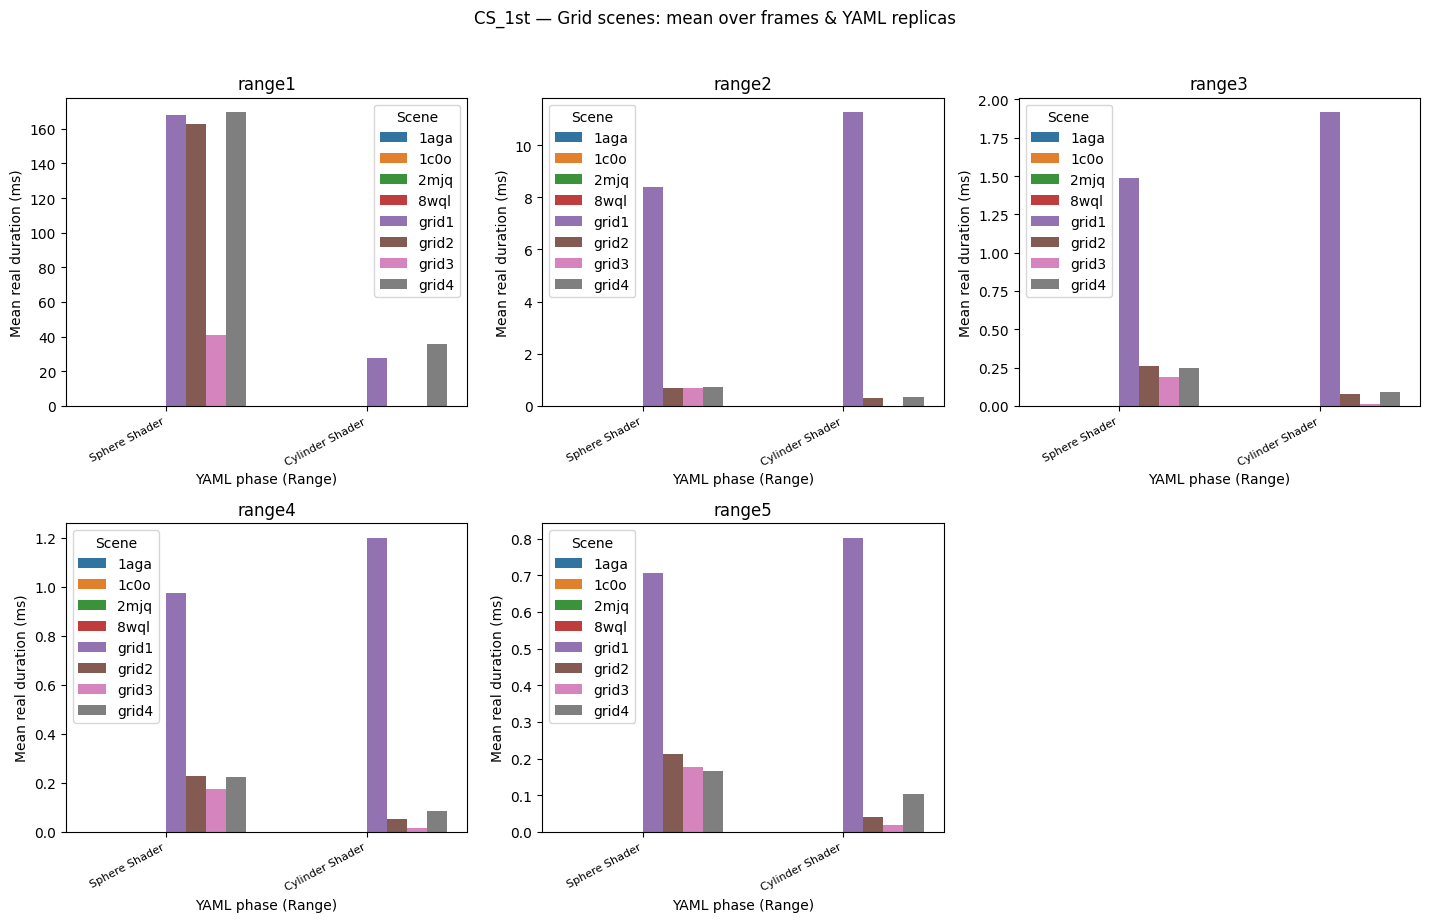

## 4 — Version `CS_2nd`: selected phases (mean ms)

### Molecular scenes

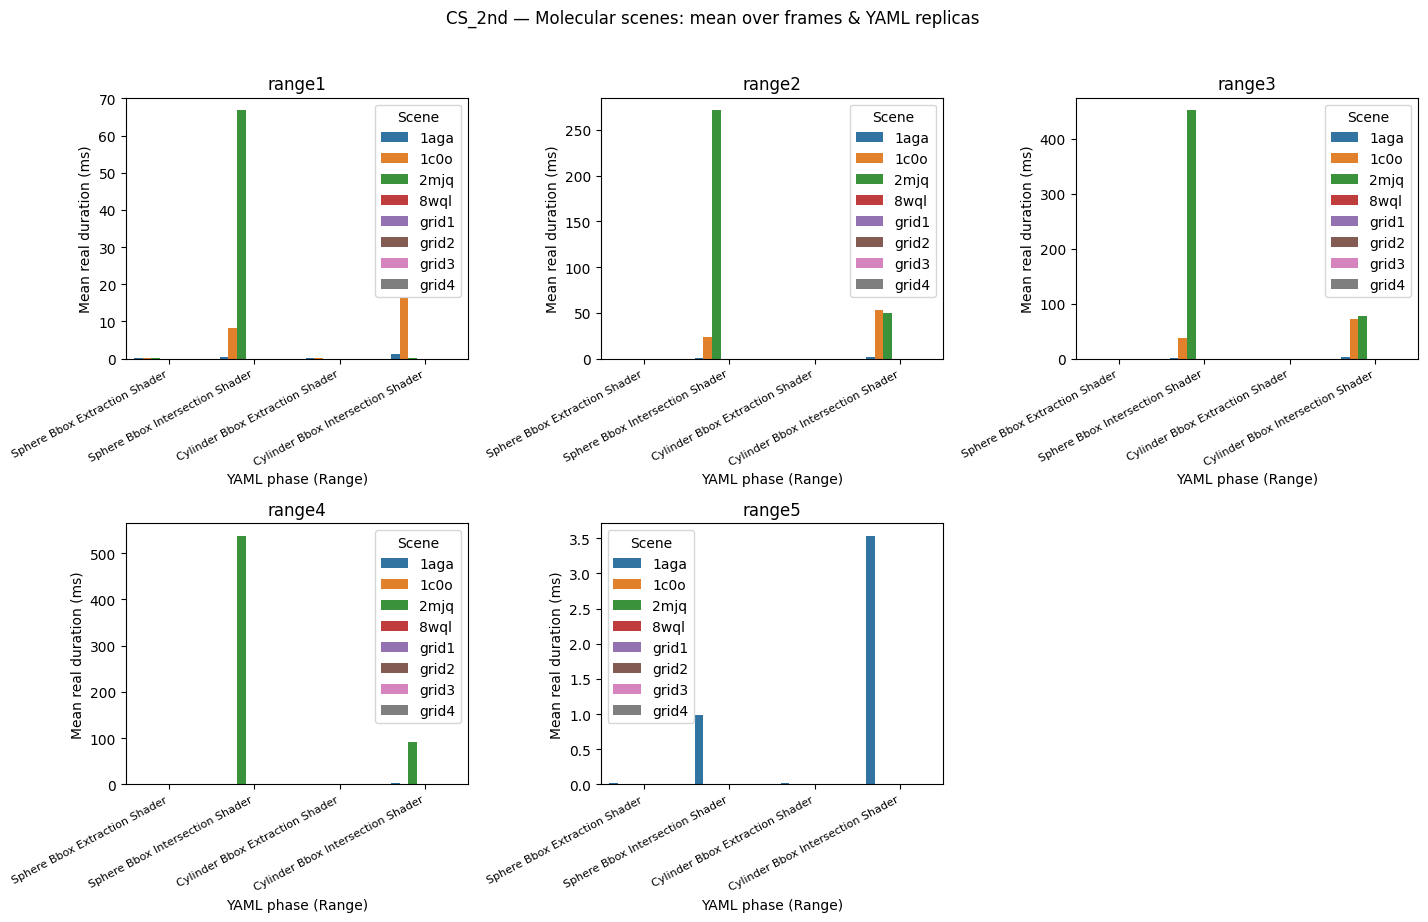

### Grid scenes

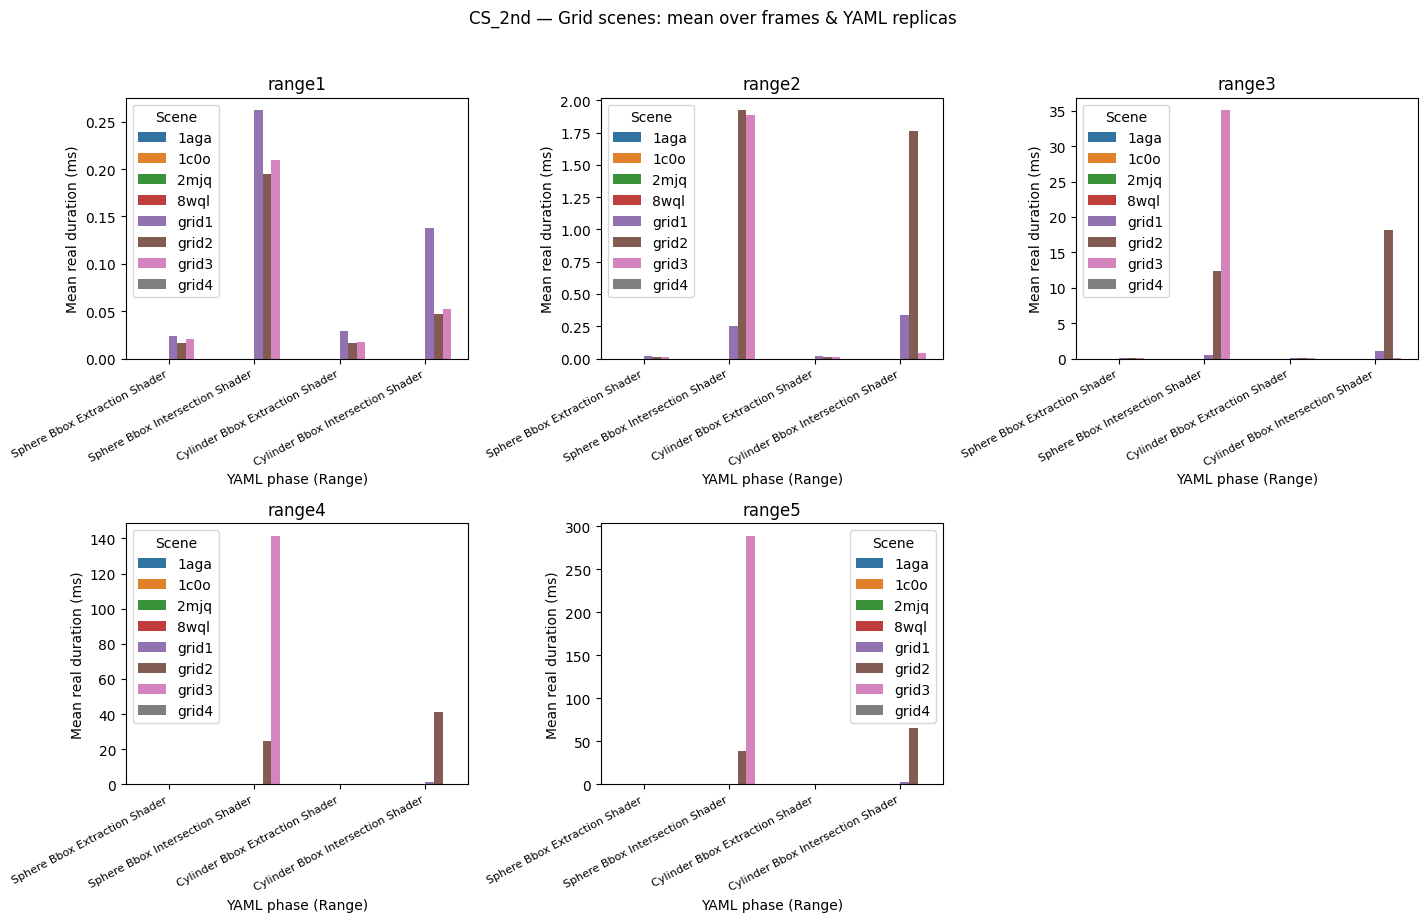

## 4 — Version `CS_std`: selected phases (mean ms)

### Molecular scenes

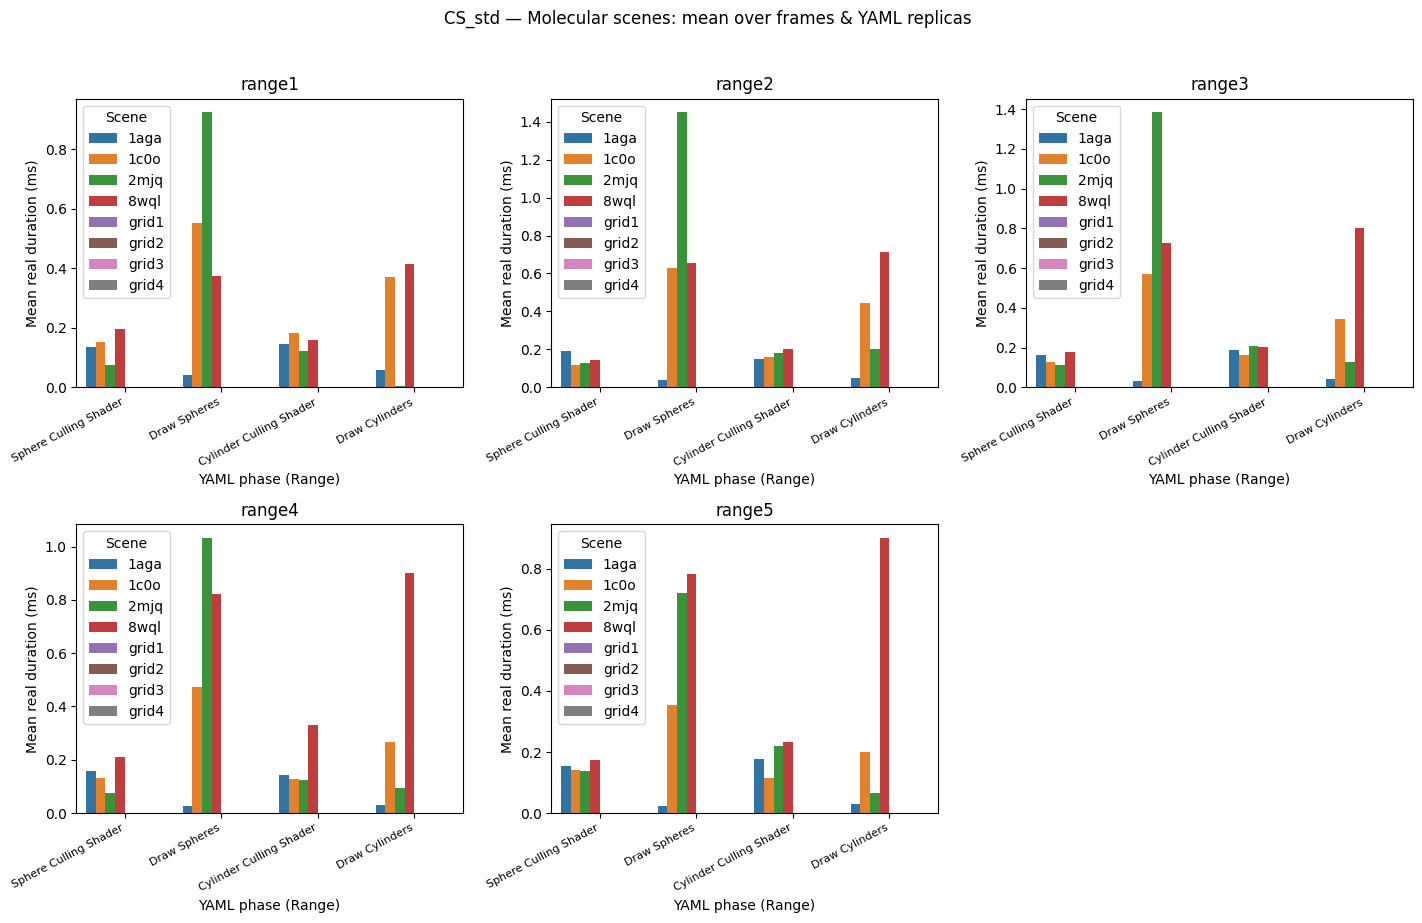

### Grid scenes

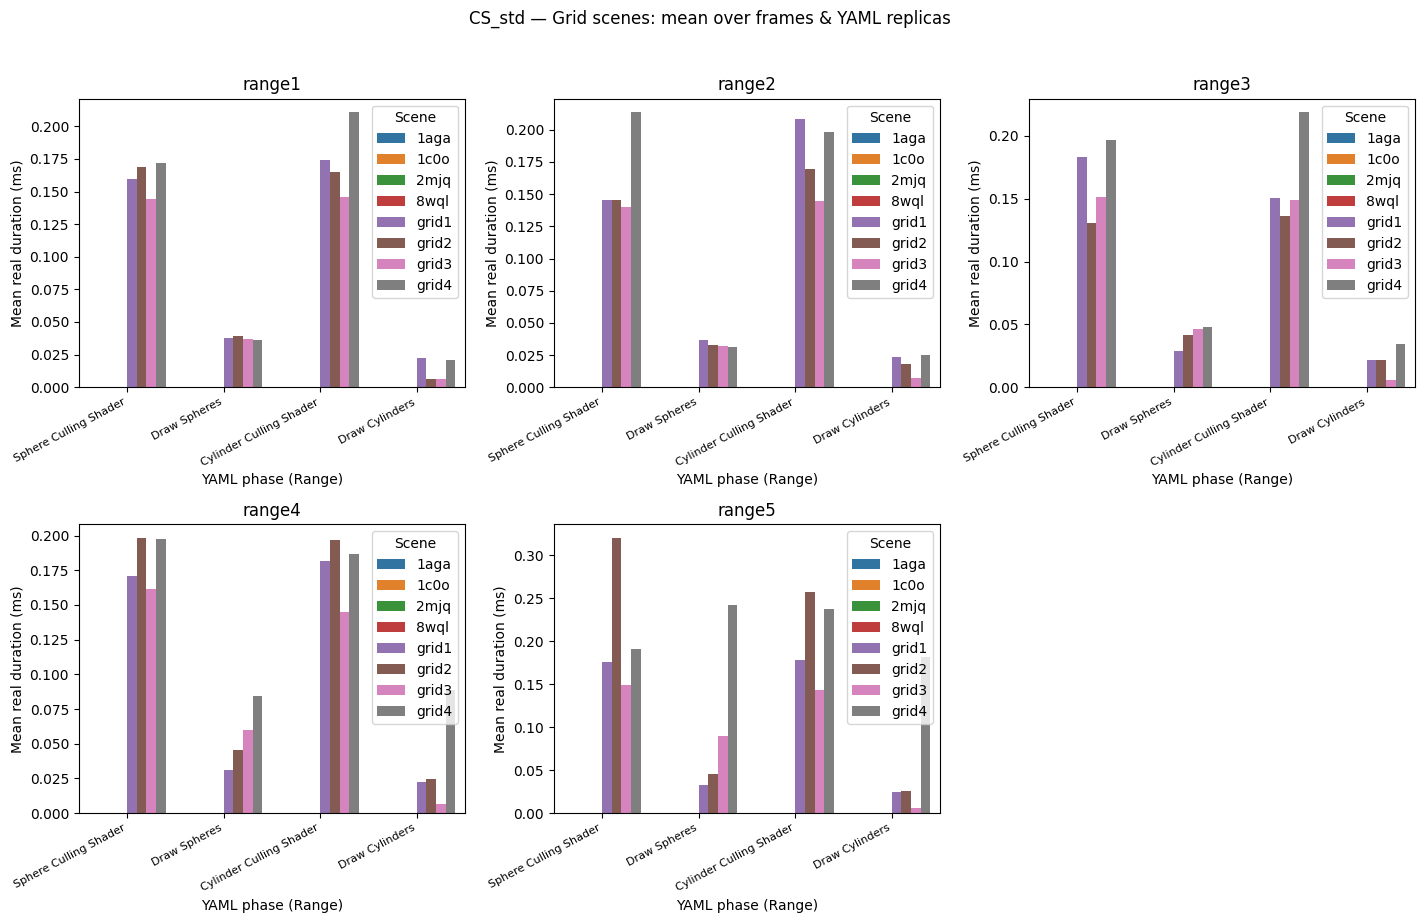

## 4 — Version `CU_HYB_BIN`: selected phases (mean ms)

### Molecular scenes

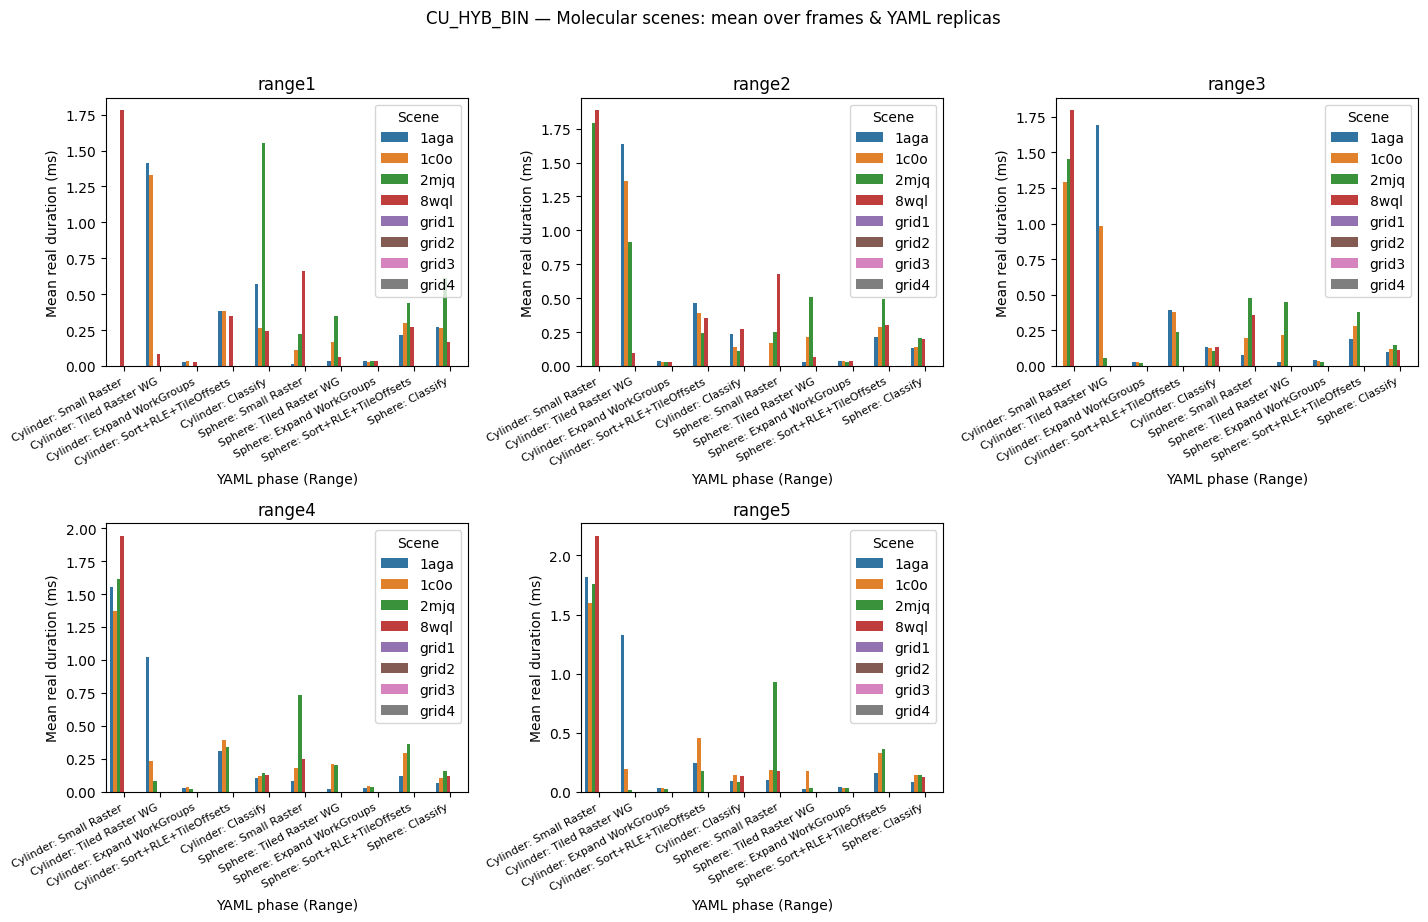

### Grid scenes

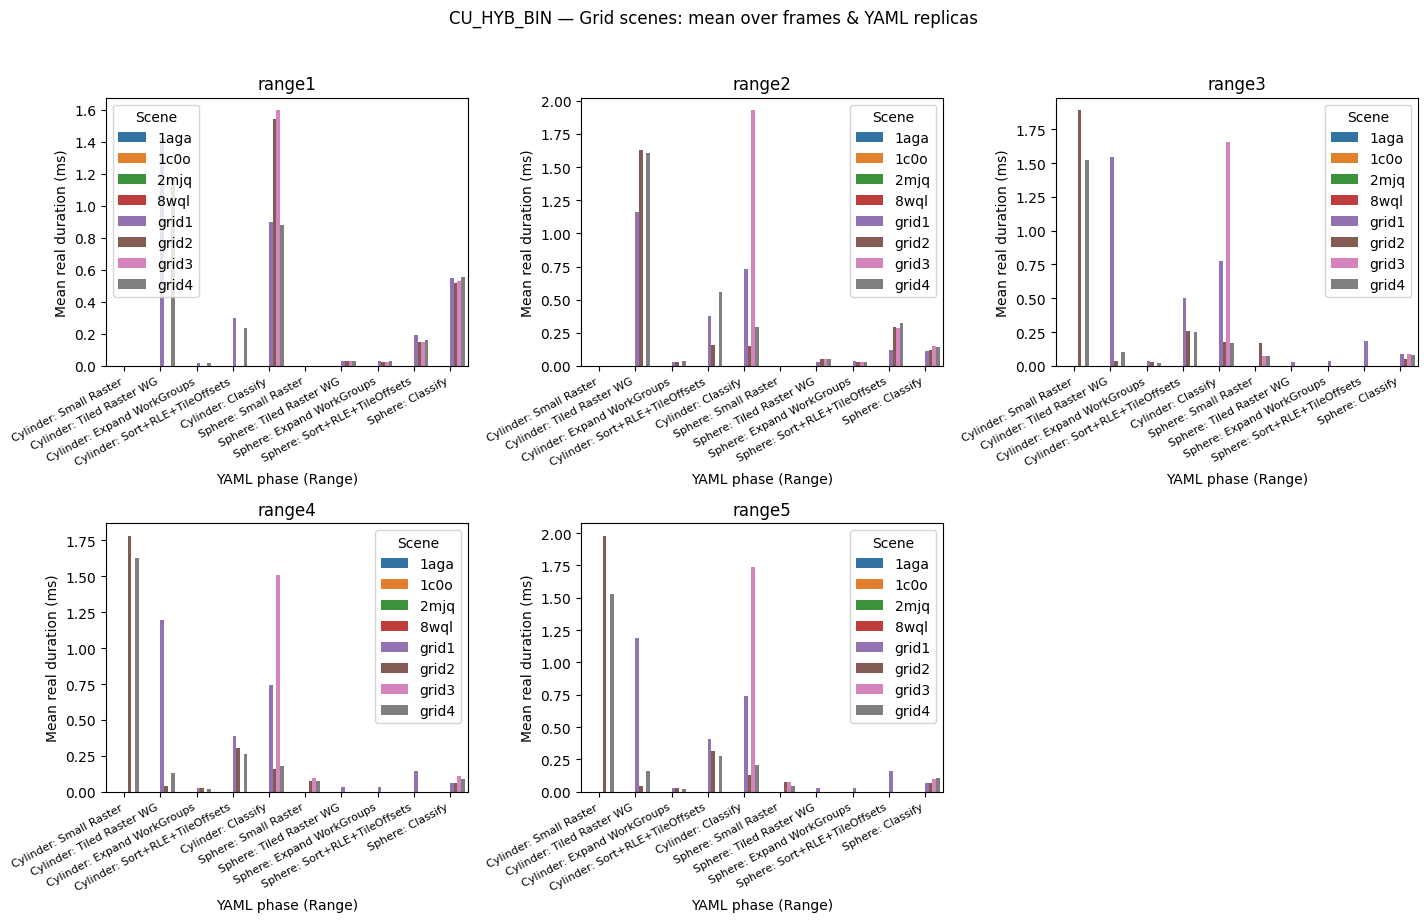

In [127]:
import math

for v in VERSIONES:
    if v not in PHASES_BY_VERSION:
        continue
    phases = list(PHASES_BY_VERSION[v])
    display(Markdown(f"## 4 — Version `{v}`: selected phases (mean ms)"))
    for tipo in TIPOS_ESCENA:
        display(Markdown(f"### {TITULO_TIPO_ESCENA[tipo]}"))
        base = agg_phase_bars[agg_phase_bars["Version"] == v].copy()
        base["Scene_plot"] = base["Scene"].astype(str)
        is_grid_name = base["Scene_plot"].str.match(r"^grid\d+$", case=False, na=False)
        if tipo == "molecular":
            sub = base.loc[~is_grid_name]
        else:
            sub = base.loc[is_grid_name]
        if sub.empty:
            print("(no rows for this slice)\n")
            continue

        n_panels = len(RANGOS)
        ncols = min(3, n_panels)
        nrows = math.ceil(n_panels / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.5 * nrows), squeeze=False)
        axes_flat = axes.ravel()
        for idx, cr in enumerate(RANGOS):
            ax = axes_flat[idx]
            d = sub.loc[sub["CameraRange"] == cr, ["Phase", "Mean_ms", "Scene_plot"]].copy()
            if d.empty:
                ax.set_visible(False)
                continue
            present = [p for p in phases if p in set(d["Phase"])]
            if not present:
                ax.set_visible(False)
                continue
            d["Phase"] = pd.Categorical(d["Phase"], categories=present, ordered=True)
            hue_order = sorted(d["Scene_plot"].unique())
            sns.barplot(
                data=d,
                x="Phase",
                y="Mean_ms",
                hue="Scene_plot",
                hue_order=hue_order,
                ax=ax,
                dodge=True,
                errorbar=None,
            )
            ax.set_title(str(cr))
            ax.set_xlabel("YAML phase (Range)")
            ax.set_ylabel("Mean real duration (ms)")
            plt.setp(ax.get_xticklabels(), rotation=28, ha="right", fontsize=8)
            if ax.legend_ is not None:
                ax.legend_.set_title("Scene")
        for j in range(n_panels, len(axes_flat)):
            axes_flat[j].set_visible(False)
        fig.suptitle(
            f"{v} — {TITULO_TIPO_ESCENA[tipo]}: mean over frames & YAML replicas",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()
